# Human MoTrPAC: searching beyond CCN1 for candidate protein exerkines

**Question:** Which circulating proteins respond to acute exercise and also have supporting tissue responses, and which deserve mechanistic follow-up?

**Main result:** At source BH < 0.05, 142 genes have a positive plasma response relative to resting controls. Fifteen also have positive muscle/adipose RNA or total-protein responses after the **same exercise mode**. We prioritize **CD300LG** for diabetes-related follow-up, **ANGPT2** for vascular remodeling, and **WARS1** for exploratory immune signaling. CCN1 and CX3CL1 are previously analyzed benchmarks.

Fourteen of the 15 are already in the MoTrPAC landscape preprint's Table S8; WARS1 is absent, including its alias WARS. This is an extension of that particular list, **not a claim of a newly discovered exerkine**. The candidates' tissue responses occur after their significant plasma responses at the sampled times. These data do not establish tissue of secretion, target-organ action, or benefit in diabetes.

This notebook uses existing human c2.0 data and saved external annotations. It can run offline once its inputs are present. It reproduces BH from consortium raw p-values; it does not refit participant-level differential models. Analysis date: 26 September 2026.

## Data, contrasts, and the null hypothesis

The source is **Acute Exercise in Human Sedentary Adults**, `human-precovid-sed-adu`, collection c2.0; package `MotrpacHumanPreSuspensionAnalysis` 2.0.8 at commit `535b4044e7417413de471104c619120337602b77`. The cohort contains 175 participants across the study, with assay-specific sample availability. These are responses to a **single bout**, not estimates of long-term training adaptations. [Pinned source package](https://github.com/MoTrPAC/MotrpacHumanPreSuspensionAnalysis/tree/535b4044e7417413de471104c619120337602b77).

For a protein and timepoint, the primary contrast is:

\[
\beta_{EE-CON,t} = (EE_t-EE_{baseline})-(CON_t-CON_{baseline}).
\]

The raw p-value tests **H₀: this difference in changes is zero**. RE-CON substitutes resistance for endurance. A positive effect means a greater change than in controls; it need not mean an absolute within-exercise-arm increase. “Up” below always means this positive control-adjusted effect.

MoTrPAC supplied effects (`logFC`), raw p-values, source BH-adjusted p-values, and pointwise 95% confidence intervals. We retain the native effect scales; effects are not absolute circulating concentrations, and RNA/protein magnitudes are not pooled.

**BH changes the rejection rule, not the biological comparison.** It corrects for testing all features within each tissue × assay × platform × contrast. Here each plasma family includes 1,417 Olink features. Under the method's assumptions, BH targets an expected false-discovery proportion among rejected hypotheses in that family. It does not assign each candidate a probability of being false. Selecting genes across times and omics afterward does not supply a new 5% FDR guarantee for our final shortlist.

In [1]:
from pathlib import Path
import sys, subprocess, importlib.util, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if not (ROOT / 'motrpac-exploration').exists():
    ROOT = ROOT / 'bic'
assert (ROOT / 'motrpac-exploration').exists(), 'Run from the bic directory or its parent.'
OUT = ROOT / 'results/exerkine_screen'
OUT.mkdir(parents=True, exist_ok=True)
spec = importlib.util.spec_from_file_location('exerkine_screen', ROOT / 'analysis/screen_exerkines.py')
screen_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(screen_module)
hashes = screen_module.verify_inputs(ROOT)
print(f'Verified {len(hashes)} original input checksums against the pinned provenance.')
pd.set_option('display.max_colwidth', 85)
pd.set_option('display.max_rows', 60)

Verified 7 original input checksums against the pinned provenance.


## Recompute the full assay corrections before selecting genes

The base-R extractor reads six differential-result objects: plasma Olink, blood RNA, muscle RNA, adipose RNA, muscle total protein, and adipose total protein. It recomputes BH over **every feature in each source family** before retaining gene-matched tissue rows. Blood RNA is saved for context but cannot satisfy the muscle/adipose criterion. Phosphosites are excluded from this abundance screen: phosphorylation is not evidence of increased protein production or secretion.

Only exercise-versus-control and direct EE-RE comparisons are extracted. Three plasma features with absent or ambiguous gene assignments remain in the BH denominator but cannot nominate a uniquely identified gene.

In [2]:
import shutil
rscript = shutil.which('Rscript')
assert rscript, 'Rscript is required for independent full-assay extraction.'
completed = subprocess.run([
    rscript, str(ROOT / 'analysis/extract_exerkine_screen.R'),
    str(ROOT / 'motrpac-exploration'), str(OUT)
], check=True, text=True, capture_output=True)
print(completed.stdout)
result = screen_module.build_screen(ROOT)
background = result['full']
plasma = result['plasma']
tissue = result['tissue']
primary = result['primary']
pairs = result['pairs']
counts = result['counts']
print(json.dumps(counts, indent=2))
display(result['audit'].groupby(['tissue', 'assay']).agg(
    contrasts=('contrast', 'size'), feature_tests=('n_features', 'sum'),
    largest_BH_difference=('max_BH_difference', 'max')).reset_index())

BLOOD_PROT_OL_DA : retained 19838 gene-matched rows after full-assay BH validation
BLOOD_TRNSCRPT_DA : retained 14714 gene-matched rows after full-assay BH validation
MUSCLE_TRNSCRPT_DA : retained 8847 gene-matched rows after full-assay BH validation
ADIPOSE_TRNSCRPT_DA : retained 10404 gene-matched rows after full-assay BH validation
MUSCLE_PROT_PR_DA : retained 5229 gene-matched rows after full-assay BH validation
ADIPOSE_PROT_PR_DA : retained 2193 gene-matched rows after full-assay BH validation



{
  "source_BH_families_validated": 58,
  "source_feature_contrasts_validated": 713660,
  "max_BH_difference": 4.44089209850063e-15,
  "plasma_assay_features": 1417,
  "plasma_primary_tests": 14170,
  "plasma_features_unmapped_or_ambiguous": 3,
  "primary_plasma_up_genes": 142,
  "primary_same_mode_genes": 15,
  "primary_explicit_secreted_location_genes": 3,
  "primary_any_tissue_at_or_before_plasma": 0,
  "exploratory_010_plasma_up_genes": 247,
  "exploratory_010_same_mode_genes": 38,
  "pooled_BH_positive_plasma_genes": 97,
  "uniprot_accessions_annotated": 248,
  "published_table_s8_genes": 168,
  "primary_genes_in_published_table_s8": 14,
  "primary_genes_absent_published_table_s8": [
    "WARS1"
  ],
  "benchmarks_reproduced": {
    "CCN1": 10,
    "CX3CL1": 10
  }
}


,tissue,assay,contrasts,feature_tests,largest_BH_difference
0,adipose,prot-pr,3,21168,2.997602e-15
1,adipose,transcript-rna-seq,9,180810,3.885781e-15
2,blood,prot-ol,14,19838,4.107825e-15
3,blood,transcript-rna-seq,14,287364,4.440892e-15
4,muscle,prot-pr,9,55899,3.108624e-15
5,muscle,transcript-rna-seq,9,148581,3.441691e-15


In [3]:
# A second, visible Python BH verification of all 14 plasma comparison families.
def bh_adjust(values):
    p = np.asarray(values, dtype=float)
    assert np.isfinite(p).all() and ((p >= 0) & (p <= 1)).all()
    order = np.argsort(p, kind='stable')
    adjusted_sorted = np.minimum.accumulate(
        (p[order] * len(p) / np.arange(1, len(p) + 1))[::-1])[::-1]
    out = np.empty(len(p))
    out[order] = np.minimum(adjusted_sorted, 1)
    return out

family = ['tissue', 'assay', 'platform', 'contrast']
recomputed = background.groupby(family, observed=True, dropna=False).p_value.transform(bh_adjust)
np.testing.assert_allclose(recomputed, background.adj_p_value, rtol=1e-10, atol=1e-12)
display(result['audit'].query("assay == 'prot-ol'")[
    ['contrast_category', 'Timepoint', 'n_features', 'source_FDR_hits', 'source_FDR_up']])

,contrast_category,Timepoint,n_features,source_FDR_hits,source_FDR_up
0,EE-CON,during_20_min,1417,33,31
1,EE-CON,during_40_min,1417,133,130
2,EE-CON,post_10_min,1417,18,18
3,EE-CON,post_15_30_45_min,1417,7,6
4,EE-CON,post_3.5_4_hr,1417,8,1
5,EE-CON,post_24_hr,1417,1,1
6,RE-CON,post_10_min,1417,43,28
7,RE-CON,post_15_30_45_min,1417,48,7
8,RE-CON,post_3.5_4_hr,1417,47,1
9,RE-CON,post_24_hr,1417,2,0


## Screening rule and annotation checks

The primary screen requires **source BH < 0.05 and positive effect** in plasma and in muscle/adipose RNA or total protein, for the **same gene and exercise mode**. Any measured times may match, but all time pairs remain visible. The minimum q-values in summaries can come from different times; they are not combined p-values.

Then we review whether extracellular signaling is plausible. UniProt's structured location annotation identifies explicitly secreted proteins. A signal peptide alone does not distinguish a secreted protein from a membrane protein. Lack of a “Secreted” annotation is not proof against secretion: CD300LG has human exercise evidence despite being a membrane protein, and WARS1 has experimental evidence for nonclassical secretion.

Annotation responses for 248 accessions are cached and checked for coverage. Published candidate status uses the original, checksum-verified **Table S8, `Exerkine_Candidate_List` sheet**, from the [MoTrPAC landscape preprint](https://doi.org/10.64898/2026.02.27.702183). Atlas membership uses the previously cached [Exerkine Atlas](https://exerkineatlas.org/) gene mapping. Absence from either list cannot establish literature-wide novelty. Our same-mode 0.05 screen is an adaptation, not a reproduction of the preprint's broader 0.10 screen.

In [4]:
# This is a nomination rule, not an additional statistical test.
p_up = plasma[(plasma.adj_p_value < .05) & (plasma.logFC > 0)]
t_up = tissue[(tissue.adj_p_value < .05) & (tissue.logFC > 0)]
matched = p_up[['gene_symbol', 'contrast_category']].drop_duplicates().merge(
    t_up[['gene_symbol', 'contrast_category']].drop_duplicates(),
    on=['gene_symbol', 'contrast_category'])
assert set(matched.gene_symbol) == set(primary.gene_symbol)
display(primary[['gene_symbol', 'min_plasma_q', 'min_tissue_q', 'matched_modes',
                 'supporting_tissues', 'supporting_assays', 'location_has_secreted',
                 'in_published_table_s8', 'priority']])
print('All 142 plasma-up genes are retained in all_primary_plasma_up_genes.csv.')
print('Three primary genes have explicit UniProt secreted locations:',
      ', '.join(primary.loc[primary.location_has_secreted, 'gene_symbol']))

,gene_symbol,min_plasma_q,min_tissue_q,matched_modes,supporting_tissues,supporting_assays,location_has_secreted,in_published_table_s8,priority
0,NADK,7.372493e-08,7.902082e-10,EE-CON;RE-CON,muscle,transcript-rna-seq,False,True,Hold: extracellular signaling evidence requires review
1,SERPINB8,1.603515e-05,5.633514e-05,EE-CON;RE-CON,muscle,transcript-rna-seq,False,True,Hold: extracellular signaling evidence requires review
2,ANGPT2,2.056093e-04,9.854008e-04,EE-CON,muscle,transcript-rna-seq,True,True,Priority: vascular remodeling
3,CX3CL1,2.274168e-04,5.500778e-53,EE-CON,adipose;muscle,transcript-rna-seq,True,True,Previously analyzed benchmark
4,CCN1,1.022285e-03,2.929575e-34,EE-CON;RE-CON,adipose;muscle,prot-pr;transcript-rna-seq,True,True,Previously analyzed benchmark
5,PXN,1.022285e-03,7.629831e-04,RE-CON,muscle,transcript-rna-seq,False,True,Hold: extracellular signaling evidence requires review
6,CD300LG,1.757265e-03,3.797813e-03,EE-CON,muscle,transcript-rna-seq,False,True,Priority: diabetes follow-up
7,ACVRL1,9.328869e-03,2.605462e-04,RE-CON,muscle,transcript-rna-seq,False,True,Hold: extracellular signaling evidence requires review
8,EGLN1,1.579128e-02,9.023502e-19,RE-CON,muscle,transcript-rna-seq,False,True,Hold: extracellular signaling evidence requires review
9,SCLY,2.240800e-02,2.004957e-02,EE-CON;RE-CON,adipose;muscle,prot-pr;transcript-rna-seq,False,True,Hold: extracellular signaling evidence requires review


All 142 plasma-up genes are retained in all_primary_plasma_up_genes.csv.
Three primary genes have explicit UniProt secreted locations: ANGPT2, CX3CL1, CCN1


## Shortlist with exact timepoints

The table below shows each selected gene's strongest qualifying **plasma–tissue evidence pair** in the matched mode. It includes the separate raw p-values, source q-values and effect estimates. The all-pairs export prevents this representative row from hiding other timepoints.

CD300LG and ANGPT2 meet the criterion after endurance; WARS1 meets it after resistance. This does **not** prove a difference between exercise modes. A significant result in one mode and a nonsignificant result in the other is not a direct modality test.

In [5]:
PRIORITY = ['CD300LG', 'ANGPT2', 'WARS1']
selected = pairs[pairs.gene_symbol.isin(PRIORITY)].sort_values(
    ['adj_p_value_plasma', 'adj_p_value_tissue']).drop_duplicates('gene_symbol')
selected = selected.set_index('gene_symbol').loc[PRIORITY].reset_index()
selected = selected.merge(background[['feature_id', 'contrast', 'pooled_primary_plasma_bh']],
                          left_on=['feature_id_plasma', 'contrast_plasma'], right_on=['feature_id', 'contrast'],
                          validate='one_to_one')
selected.to_csv(OUT / 'priority_evidence_summary.csv', index=False)
display(selected[['gene_symbol', 'contrast_category', 'feature_id_plasma', 'sample_time_plasma',
                  'logFC_plasma', 'p_value_plasma', 'adj_p_value_plasma',
                  'tissue_tissue', 'assay_tissue', 'sample_time_tissue',
                  'logFC_tissue', 'p_value_tissue', 'adj_p_value_tissue',
                  'pooled_primary_plasma_bh']])
print('Primary genes with a qualifying tissue response at/before a qualifying plasma response:',
      counts['primary_any_tissue_at_or_before_plasma'], 'of', counts['primary_same_mode_genes'])

,gene_symbol,contrast_category,feature_id_plasma,sample_time_plasma,logFC_plasma,p_value_plasma,adj_p_value_plasma,tissue_tissue,assay_tissue,sample_time_tissue,logFC_tissue,p_value_tissue,adj_p_value_tissue,pooled_primary_plasma_bh
0,CD300LG,EE-CON,OID21130,during 40 min,0.696146,0.000045,0.001757,muscle,transcript-rna-seq,post 3.5 h,0.438777,2.541997e-04,0.003798,0.005804
1,ANGPT2,EE-CON,OID21463,during 40 min,0.401347,0.000002,0.000206,muscle,transcript-rna-seq,post 3.5 h,0.717250,4.936256e-05,0.000985,0.000832
2,WARS1,RE-CON,OID21084,post 10 min,0.566828,0.000734,0.031163,muscle,transcript-rna-seq,post 3.5 h,0.329233,3.147579e-07,0.000004,0.040771


Primary genes with a qualifying tissue response at/before a qualifying plasma response: 0 of 15


**Timing is a major limitation.** None of the 15 primary genes has a qualifying sampled tissue increase at or before its qualifying plasma increase. For the three priorities, muscle RNA rises at 3.5 hours, after the early plasma signal. Later RNA could reflect replenishment or a separate response; that is a hypothesis. It cannot explain an earlier circulating pulse through newly transcribed RNA. Stored-protein release, other tissues/cell types, shedding, vesicles, altered clearance, plasma-volume changes, and cell injury remain alternatives. Bulk biopsy expression does not isolate muscle fibers from vascular or immune cells.

This screen can also miss real exerkines: release need not require transcriptional induction, candidate proteins may be absent from Olink, and the source may be an unmeasured organ. Our 15-gene overlap is a selected subset, not a census of exerkines.

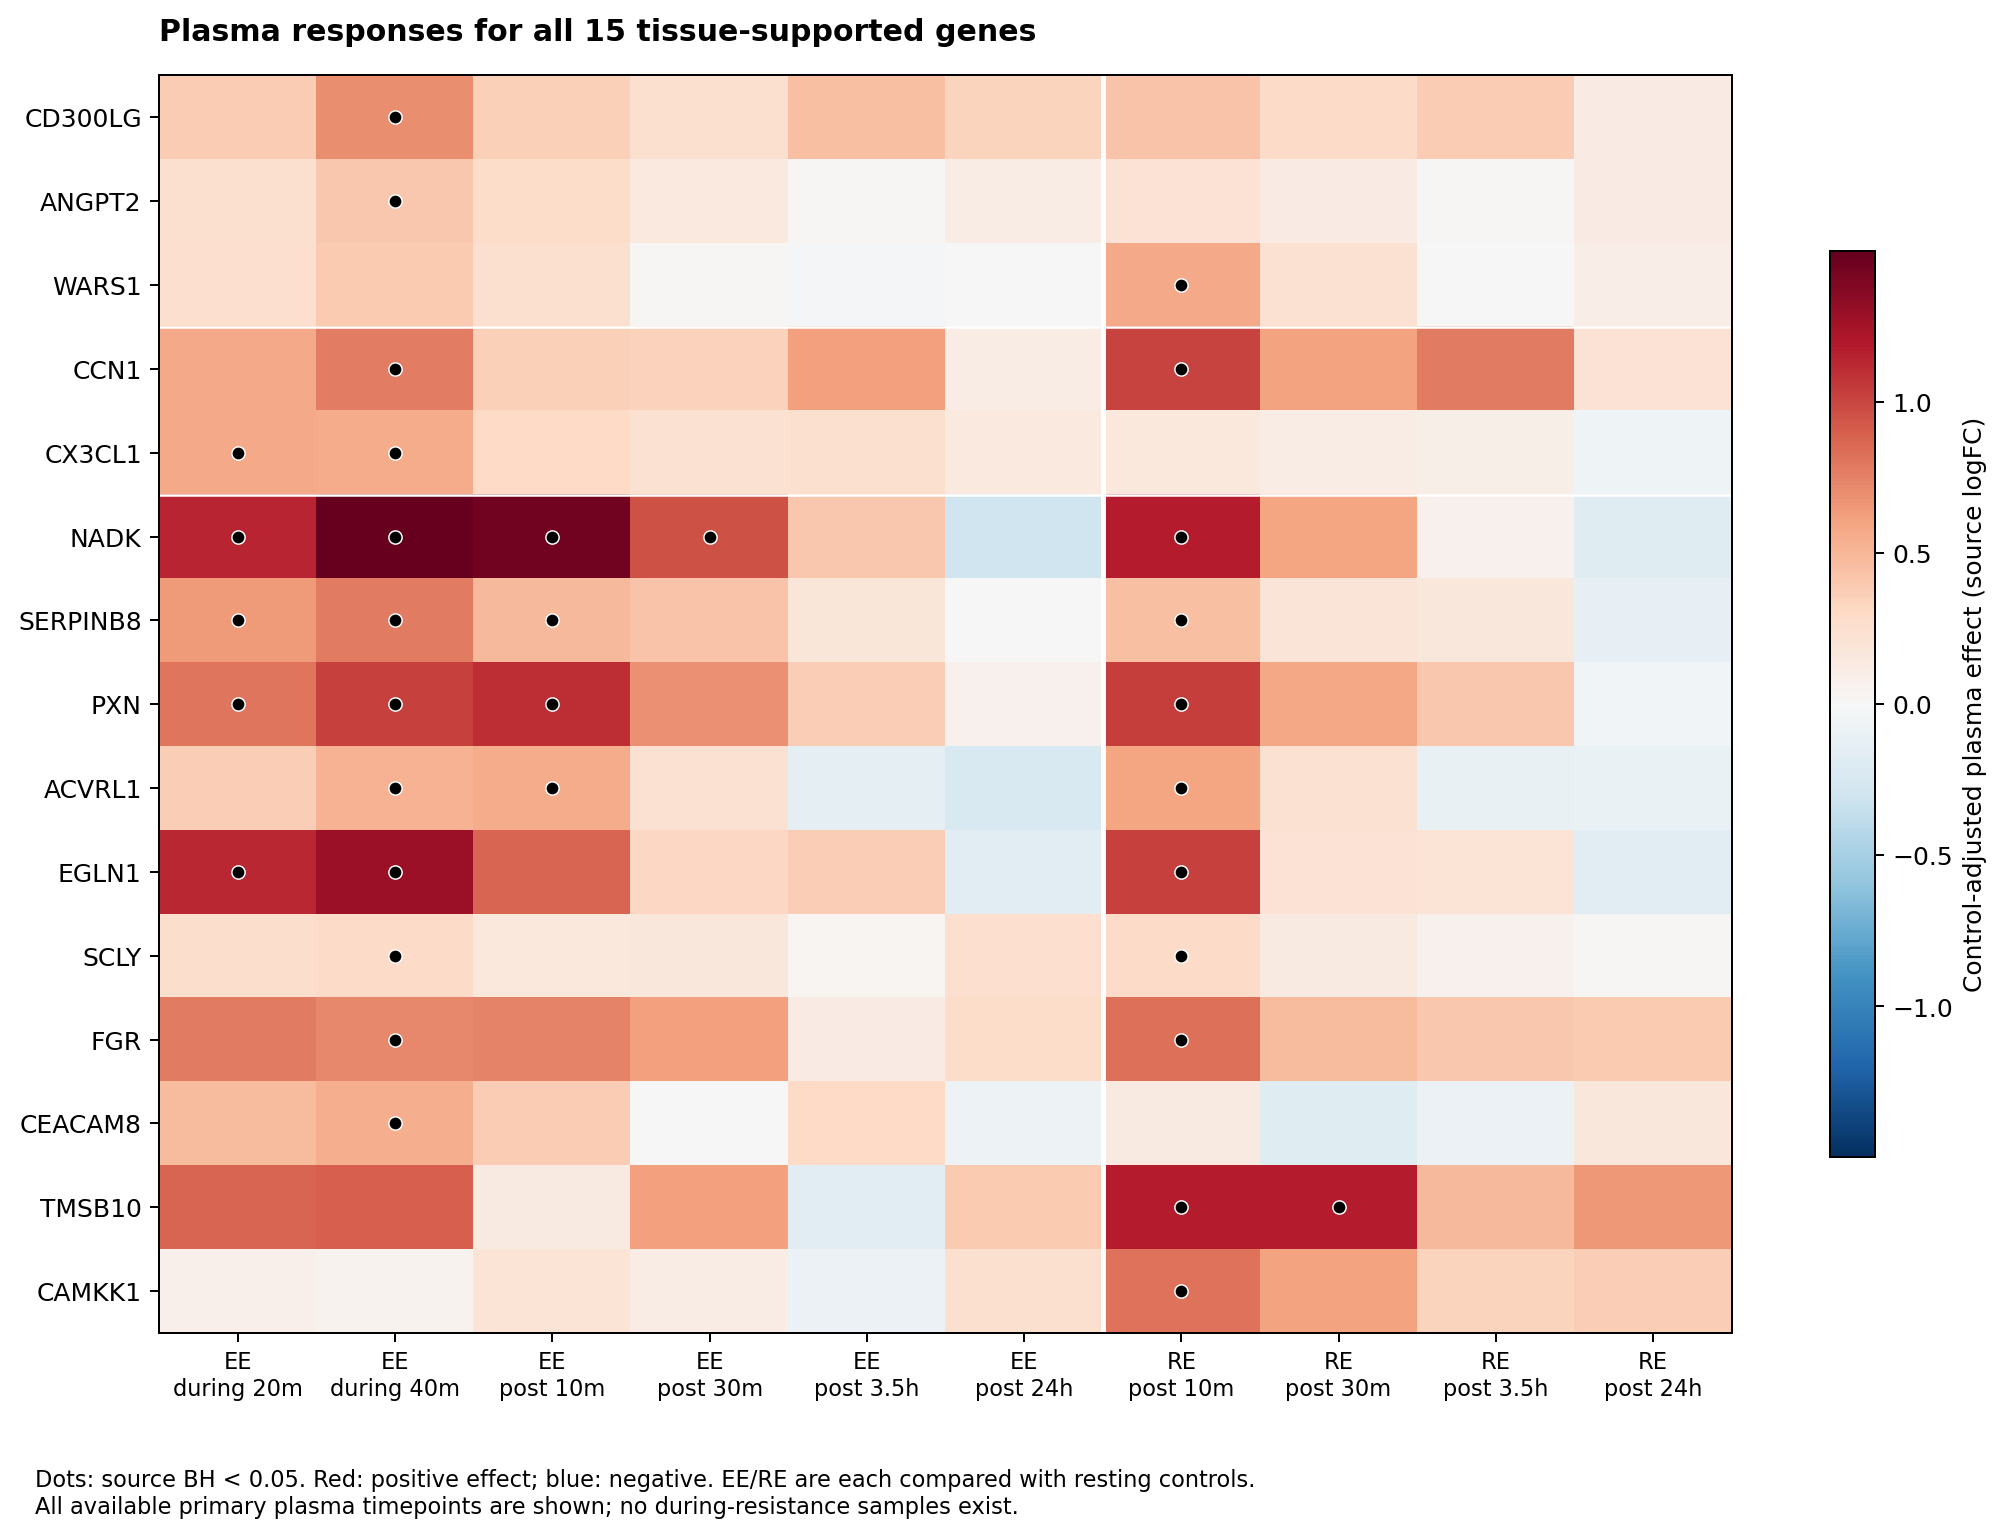

In [6]:
COLORS = {'EE-CON': '#2267a4', 'RE-CON': '#bd5c29'}
def save_figure(fig, stem):
    fig.savefig(OUT / f'{stem}.png', dpi=180, facecolor='white', bbox_inches='tight')
    fig.savefig(OUT / f'{stem}.svg', facecolor='white', bbox_inches='tight')
    display(Image(filename=str(OUT / f'{stem}.png')))
    plt.close(fig)

times = ['during_20_min', 'during_40_min', 'post_10_min',
         'post_15_30_45_min', 'post_3.5_4_hr', 'post_24_hr']
columns = [('EE-CON', t) for t in times] + [('RE-CON', t) for t in times[2:]]
labels = ['EE\nduring 20m', 'EE\nduring 40m', 'EE\npost 10m', 'EE\npost 30m', 'EE\npost 3.5h', 'EE\npost 24h',
          'RE\npost 10m', 'RE\npost 30m', 'RE\npost 3.5h', 'RE\npost 24h']
genes = PRIORITY + ['CCN1', 'CX3CL1'] + [g for g in primary.gene_symbol if g not in PRIORITY + ['CCN1', 'CX3CL1']]
plot_data = plasma[plasma.gene_symbol.isin(genes)]
assert not plot_data.duplicated(['gene_symbol', 'contrast_category', 'Timepoint']).any()
effects = plot_data.pivot(index='gene_symbol', columns=['contrast_category', 'Timepoint'], values='logFC').reindex(index=genes, columns=columns)
qvals = plot_data.pivot(index='gene_symbol', columns=['contrast_category', 'Timepoint'], values='adj_p_value').reindex(index=genes, columns=columns)
assert effects.notna().all().all()
fig, ax = plt.subplots(figsize=(12, 8.6))
limit = np.abs(effects.to_numpy()).max()
im = ax.imshow(effects, cmap='RdBu_r', vmin=-limit, vmax=limit, aspect='auto')
rr, cc = np.where(qvals.to_numpy() < .05)
ax.scatter(cc, rr, color='black', edgecolor='white', linewidth=.6, s=28)
ax.set_xticks(range(len(labels)), labels, fontsize=9)
ax.set_yticks(range(len(genes)), genes)
ax.axvline(5.5, color='white', linewidth=2)
ax.axhline(2.5, color='white', linewidth=1)
ax.axhline(4.5, color='white', linewidth=1)
ax.set_title('Plasma responses for all 15 tissue-supported genes', loc='left', fontweight='bold', pad=14)
fig.colorbar(im, ax=ax, shrink=.72, label='Control-adjusted plasma effect (source logFC)')
fig.text(.02, .015, 'Dots: source BH < 0.05. Red: positive effect; blue: negative. EE/RE are each compared with resting controls.\nAll available primary plasma timepoints are shown; no during-resistance samples exist.', fontsize=9)
fig.tight_layout(rect=(0, .07, 1, 1))
save_figure(fig, 'primary_candidates_plasma_heatmap')

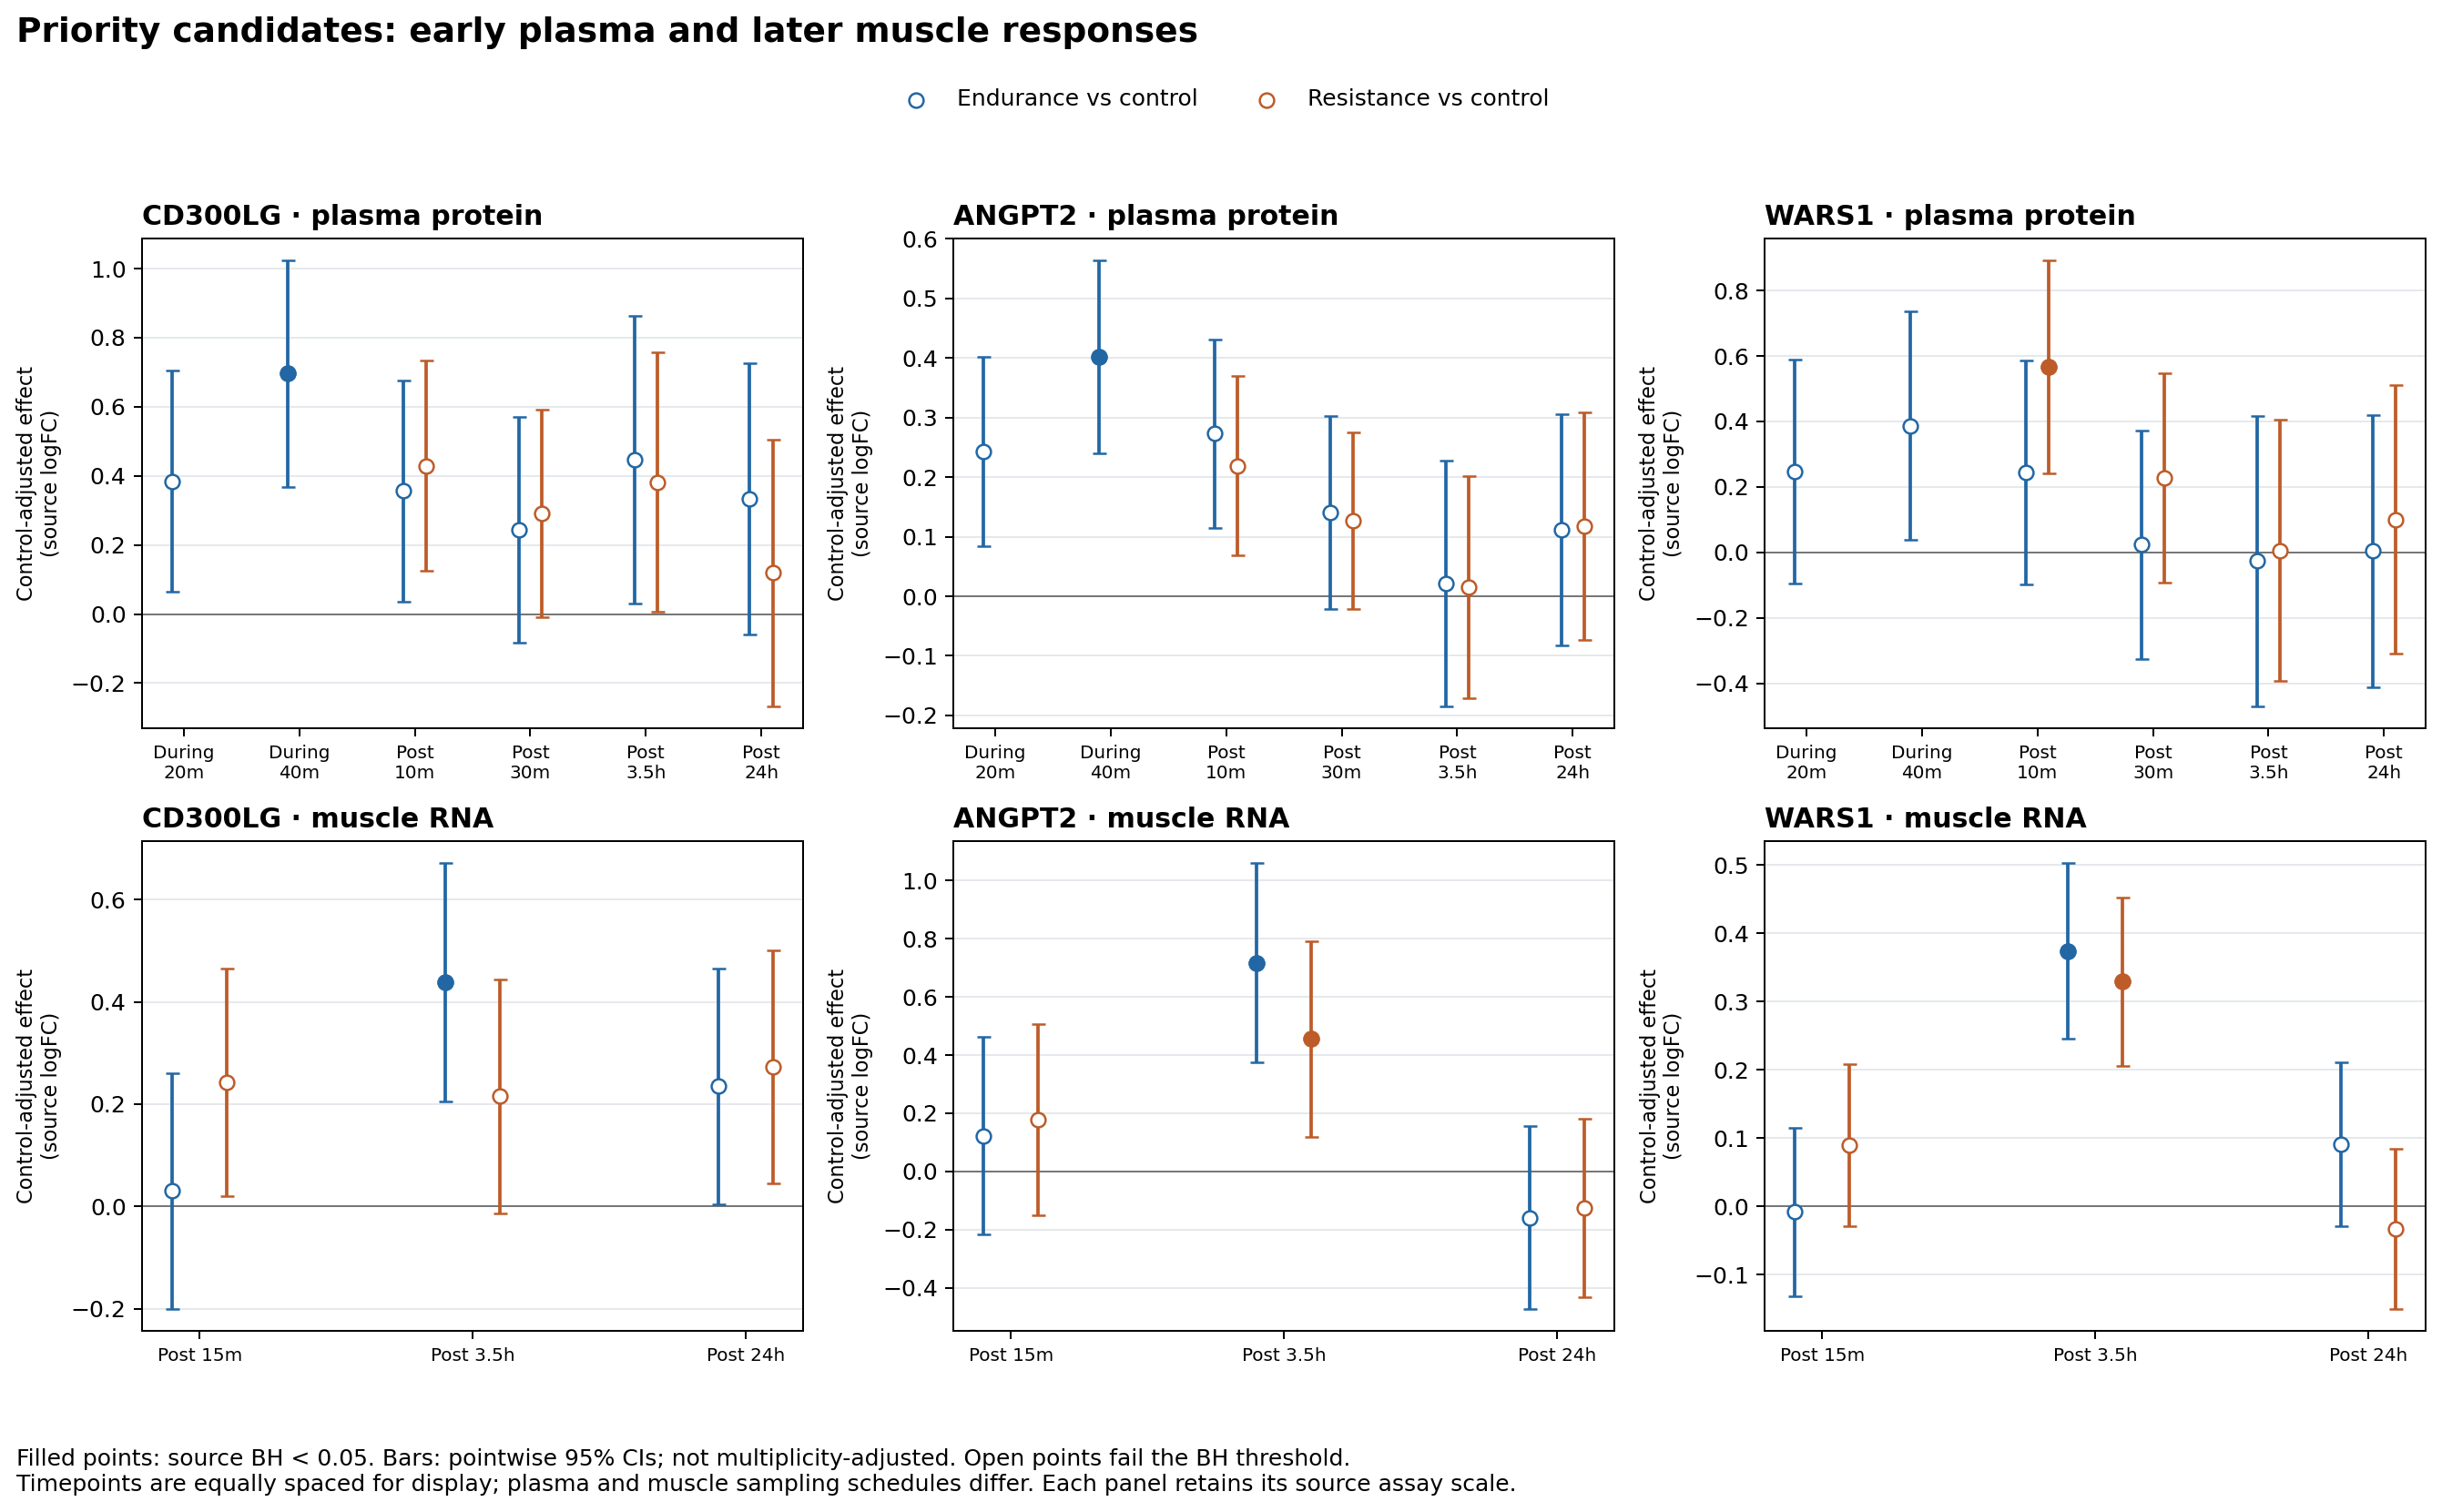

In [7]:
def response_panel(ax, frame, order, labels, title):
    ax.axhline(0, color='#777', linewidth=.8)
    for group, shift, label in [('EE-CON', -.10, 'Endurance vs control'), ('RE-CON', .10, 'Resistance vs control')]:
        q = frame[frame.contrast_category.eq(group)].copy()
        q['x'] = q.Timepoint.map({t: i for i, t in enumerate(order)})
        q = q.sort_values('x')
        if q.empty:
            continue
        x, y = q.x.to_numpy() + shift, q.logFC.to_numpy()
        error = np.vstack([y - q['CI.L_calculated'].to_numpy(), q['CI.R_calculated'].to_numpy() - y])
        assert (error >= -1e-10).all()
        ax.errorbar(x, y, yerr=np.maximum(error, 0), fmt='none', capsize=3, color=COLORS[group])
        ax.scatter(x, y, facecolor='white', edgecolor=COLORS[group], s=40, label=label, zorder=3)
        sig = q.adj_p_value.to_numpy() < .05
        ax.scatter(x[sig], y[sig], color=COLORS[group], s=40, zorder=4)
    ax.set_xticks(range(len(order)), labels, fontsize=8)
    ax.set_title(title, loc='left', fontweight='bold')
    ax.grid(axis='y', color='#e5e9ed'); ax.set_axisbelow(True)
    ax.set_ylabel('Control-adjusted effect\n(source logFC)', fontsize=9)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, gene in enumerate(PRIORITY):
    response_panel(axes[0, col], plasma[plasma.gene_symbol.eq(gene)], times,
                   ['During\n20m', 'During\n40m', 'Post\n10m', 'Post\n30m', 'Post\n3.5h', 'Post\n24h'], gene + ' · plasma protein')
    muscle = tissue[tissue.gene_symbol.eq(gene) & tissue.tissue.eq('muscle') & tissue.assay.eq('transcript-rna-seq')]
    response_panel(axes[1, col], muscle, times[3:], ['Post 15m', 'Post 3.5h', 'Post 24h'], gene + ' · muscle RNA')
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, ncol=2, loc='upper center', frameon=False, bbox_to_anchor=(.5, .975))
fig.suptitle('Priority candidates: early plasma and later muscle responses', x=.01, ha='left', fontweight='bold', fontsize=15, y=1.01)
fig.text(.01, .01, 'Filled points: source BH < 0.05. Bars: pointwise 95% CIs; not multiplicity-adjusted. Open points fail the BH threshold.\nTimepoints are equally spaced for display; plasma and muscle sampling schedules differ. Each panel retains its source assay scale.', fontsize=10)
fig.tight_layout(rect=(0, .08, 1, .94))
save_figure(fig, 'priority_plasma_muscle_timecourses')

## Biological interpretation and testable hypotheses

- **CD300LG — strongest diabetes rationale.** A 2024 study measured exercise-training responses in 26 men and linked circulating CD300LG to clamp-measured insulin sensitivity; UK Biobank and Mendelian-randomization analyses provided additional glucose-related evidence. Our acute endurance response offers a different timescale for follow-up. Its membrane localization means the measured circulating form must be resolved. Neither association nor our acute response establishes a treatment effect. [Lee-Ødegård et al., 2024](https://pubmed.ncbi.nlm.nih.gov/39190027/).
- **ANGPT2 — vascular remodeling.** It is a secreted ligand, already highlighted by MoTrPAC. Adipose-specific mouse experiments linked ANGPT2-driven vascularization to improved metabolic outcomes. This does not tell us whether an acute human circulating pulse has beneficial or harmful effects in a particular vascular bed. [An et al., 2017](https://elifesciences.org/articles/24071), [MoTrPAC preprint](https://doi.org/10.64898/2026.02.27.702183).
- **WARS1 — exploratory immune signaling.** Although usually described as a cytoplasmic tRNA synthetase, experiments demonstrate direct and vesicular secretion with extracellular innate-immune activity. The RE plasma/muscle pattern makes it worth investigating here. Those secretion experiments were not an exercise intervention; the release mechanism, active form, and disease consequence after exercise remain unknown. [Nguyen et al., 2023](https://pubmed.ncbi.nlm.nih.gov/36640342/).

The next table separates observed evidence from proposed experiments. None of these experiments has been performed in this analysis. An orthogonal protein assay is a first step: affinity-assay changes can reflect a specific epitope or fragment rather than total active protein. With only summary statistics, we cannot test within-person plasma–tissue correlations, adjust for measured plasma-volume changes, or model insulin-sensitivity outcomes.

In [8]:
display(result['curation'].set_index('gene_symbol').loc[PRIORITY,
    ['release_interpretation', 'evidence_and_limit', 'testable_follow_up', 'source_urls']])
display(primary[['gene_symbol', 'locations', 'published_COMPARTMENTS_score', 'in_published_table_s8', 'in_cached_atlas']])

,release_interpretation,evidence_and_limit,testable_follow_up,source_urls
gene_symbol,,,,
CD300LG,Membrane protein; circulating molecular form unresolved,Reported as an exercise-responsive candidate in a 2024 human training study; asso...,Identify the measured circulating fragment/full-length protein by orthogonal assa...,https://doi.org/10.7554/eLife.96535.3
ANGPT2,Secreted ligand in UniProt,Already highlighted in MoTrPAC Figure 8. Adipose-specific mouse work links ANGPT2...,Test whether post-exercise plasma changes endothelial TIE2 signaling and barrier ...,https://doi.org/10.64898/2026.02.27.702183 | https://pmc.ncbi.nlm.nih.gov/article...
WARS1,Nonclassical secretion demonstrated outside exercise,Cell experiments demonstrate soluble and vesicular WARS1 release and innate infla...,Resolve soluble versus vesicular WARS1 and cell-injury markers; test WARS1 deplet...,https://doi.org/10.1016/j.celrep.2022.111905


,gene_symbol,locations,published_COMPARTMENTS_score,in_published_table_s8,in_cached_atlas
0,NADK,,1.605,True,False
1,SERPINB8,Cytoplasm,4.265,True,False
2,ANGPT2,Secreted,5.000,True,False
3,CX3CL1,Cell membrane; Secreted,5.000,True,True
4,CCN1,Secreted,5.000,True,False
5,PXN,"Cell junction, focal adhesion; Cytoplasm, cell cortex; Cytoplasm, cytoskeleton",2.601,True,False
6,CD300LG,"Apical cell membrane; Basolateral cell membrane; Endosome, multivesicular body me...",2.246,True,False
7,ACVRL1,Cell membrane,2.873,True,False
8,EGLN1,Cytoplasm; Nucleus,2.348,True,False
9,SCLY,"Cytoplasm, cytosol",1.419,True,False


## Sensitivity analyses and secondary candidates

**Across-time plasma correction.** The source BH correction is separate for each contrast. As a sensitivity analysis we also apply BH to all 14,170 primary plasma feature × comparison tests together, before selecting genes. This is a different testing family and is not guaranteed to increase every adjusted p-value. It does not provide candidate-level FDR control for the subsequent cross-omics selection. The highlighted plasma results of all three priorities survive it.

**Threshold sensitivity.** An explicitly exploratory screen at source q < 0.10 gives 38 tissue-supported genes. HGF lacks a matching 0.05 tissue hit; STC2 and TIMP3 lack a 0.05 plasma hit. These are hypotheses for replication, not additions to the primary discoveries.

**Plasma-only examples.** FLT3LG and ANGPTL7 have strong plasma increases but fail our positive same-mode muscle/adipose criterion at 0.05. FLT3LG's acute response has been reported previously. A prior ANGPTL7 study reported lower levels after a longer training intervention in obesity; the acute increase here involves a different study and timescale. These remain useful candidates without identifying their tissue of origin. [FLT3LG human exercise study](https://pmc.ncbi.nlm.nih.gov/articles/PMC9999360/), [ANGPTL7 training study](https://doi.org/10.1371/journal.pone.0173024).

The remaining ten primary overlapping genes are retained for review. Some have extracellular annotations in COMPARTMENTS despite absent UniProt secreted-location flags. We have not established that they lack signaling roles; they are not promoted solely because their p-values are small.

In [9]:
display(selected[['gene_symbol', 'sample_time_plasma', 'adj_p_value_plasma', 'pooled_primary_plasma_bh']])
exploratory = result['exploratory']
display(exploratory[exploratory.gene_symbol.isin(['HGF', 'STC2', 'TIMP3'])][
    ['gene_symbol', 'min_plasma_q', 'min_tissue_q', 'matched_modes', 'priority']])
secondary = plasma[plasma.gene_symbol.isin(['FLT3LG', 'ANGPTL7']) & plasma.adj_p_value.lt(.05) & plasma.logFC.gt(0)]
display(secondary[['gene_symbol', 'contrast_category', 'sample_time', 'logFC', 'adj_p_value', 'pooled_primary_plasma_bh']])

,gene_symbol,sample_time_plasma,adj_p_value_plasma,pooled_primary_plasma_bh
0,CD300LG,during 40 min,0.001757,0.005804
1,ANGPT2,during 40 min,0.000206,0.000832
2,WARS1,post 10 min,0.031163,0.040771


,gene_symbol,min_plasma_q,min_tissue_q,matched_modes,priority
11,HGF,0.008076,5.136848e-02,EE-CON,Exploratory: tissue misses 0.05
23,STC2,0.060155,2.329471e-13,EE-CON,Exploratory: plasma misses 0.05
26,TIMP3,0.062823,2.262907e-02,EE-CON,Exploratory: plasma misses 0.05


,gene_symbol,contrast_category,sample_time,logFC,adj_p_value,pooled_primary_plasma_bh
8176,FLT3LG,RE-CON,post 30 min,0.358031,2.380228e-04,3.848020e-04
8177,FLT3LG,EE-CON,post 30 min,0.348820,6.766432e-03,1.851700e-03
8181,FLT3LG,RE-CON,post 10 min,0.484320,1.731789e-07,5.772631e-07
8182,FLT3LG,EE-CON,during 20 min,0.302526,6.728600e-03,8.191339e-03
8187,FLT3LG,EE-CON,post 10 min,0.465541,1.916323e-06,5.475209e-06
8189,FLT3LG,EE-CON,during 40 min,0.513698,9.670903e-08,5.802542e-07
18164,ANGPTL7,EE-CON,during 20 min,0.271245,3.845165e-02,4.677930e-02
18168,ANGPTL7,EE-CON,during 40 min,0.468005,1.120360e-05,5.601801e-05


## Direct endurance-versus-resistance tests

These tests ask whether baseline-to-timepoint changes differ between EE and RE. Positive values favor EE; negative values favor RE. They do not establish secretion or a tissue source. During-exercise direct comparisons are unavailable. All available primary-candidate plasma direct comparisons are shown, including nonsignificant results, rather than inferring modality differences from two separate control comparisons.

In [10]:
direct = background[background.gene_symbol.isin(PRIORITY) & background.contrast_category.eq('EE-RE')].copy()
direct['source_significant'] = direct.adj_p_value < .05
display(direct[['gene_symbol', 'sample_time', 'logFC', 'CI.L_calculated', 'CI.R_calculated', 'p_value', 'adj_p_value', 'source_significant']].sort_values(['gene_symbol', 'sample_time']))
direct.to_csv(OUT / 'priority_plasma_direct_mode_tests.csv', index=False)

,gene_symbol,sample_time,logFC,CI.L_calculated,CI.R_calculated,p_value,adj_p_value,source_significant
18882,ANGPT2,post 10 min,0.054266,-0.091985,0.200517,0.464769,0.789662,False
18881,ANGPT2,post 24 h,-0.005361,-0.197119,0.186398,0.956043,0.979547,False
18878,ANGPT2,post 3.5 h,0.007341,-0.191972,0.206655,0.942105,0.988378,False
18872,ANGPT2,post 30 min,0.013397,-0.133816,0.160610,0.857598,0.996227,False
14454,CD300LG,post 10 min,-0.072325,-0.367694,0.223044,0.629346,0.910100,False
14448,CD300LG,post 24 h,0.214423,-0.171515,0.600361,0.274227,0.714606,False
14451,CD300LG,post 3.5 h,0.065624,-0.335921,0.467170,0.747323,0.988378,False
14459,CD300LG,post 30 min,-0.047871,-0.345253,0.249511,0.750965,0.996227,False
13805,WARS1,post 10 min,-0.323626,-0.638796,-0.008456,0.044230,0.226947,False
13806,WARS1,post 24 h,-0.096219,-0.506429,0.313990,0.643894,0.901508,False


## Saved outputs and reproducibility

All outputs live in `results/exerkine_screen/`:

- `FINDINGS.md`: short interpretation with source links and follow-up hypotheses.
- `primary_same_mode_candidates.csv`: all 15 primary genes; source q-values and annotation caveats.
- `primary_evidence_pairs.csv`: every qualifying plasma–tissue pair, including exact sampling times.
- `all_primary_plasma_up_genes.csv`: all 142 plasma-up genes, including those without tissue overlap.
- `focal_genes_all_source_contrasts.csv`: all available focal-gene estimates, including nonsignificant results and blood RNA context.
- `priority_evidence_summary.csv` and `priority_plasma_direct_mode_tests.csv`: concise numeric results.
- `exploratory_010_same_mode_candidates.csv`: separate 0.10 threshold sensitivity.
- `bh_audit.csv`, `plasma_background_validated.csv`, `input_provenance.json`: full correction audit and hashes.
- `candidate_curation.csv`, `uniprot_annotations.csv`, `published_table_s8_extracted.csv`: annotated sources and explicit manual interpretation.
- PNG/SVG figures and cached original reference files.

The pipeline verifies 58 source BH families covering 713,660 feature–contrast tests. It reproduces the 10 earlier primary plasma contrasts for CCN1 and the 10 for CX3CL1. These are consistency checks within the same dataset, not independent replication. Annotation-based prioritization is qualitative; no combined significance score, disease enrichment test, or causal disease analysis is claimed.